<a href="https://colab.research.google.com/github/RCalvoso/grupo4_projeto_integrador_2/blob/main/06_Modelo_Multimodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dimensão final do vetor multimodal concatenado: 2873 atributos.
Epoch 1/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8137 - loss: 0.5447 - val_accuracy: 0.8933 - val_loss: 0.4790 - learning_rate: 0.0010
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9709 - loss: 0.0967 - val_accuracy: 0.9773 - val_loss: 0.0938 - learning_rate: 0.0010
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9837 - loss: 0.0543 - val_accuracy: 0.9787 - val_loss: 0.0551 - learning_rate: 0.0010
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9854 - loss: 0.0462 - val_accuracy: 0.9747 - val_loss: 0.0533 - learning_rate: 0.0010
Epoch 5/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9817 - loss: 0.0490 - val_accuracy: 0.9813 - val_loss: 0.0380 - learning_rate: 0.0010
Epoch 6/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9869 - loss: 0.0409 - val_accuracy: 0.9800 - val_loss: 0.0449 - learning_rate: 0.0010
Epoch 7/60
110/11

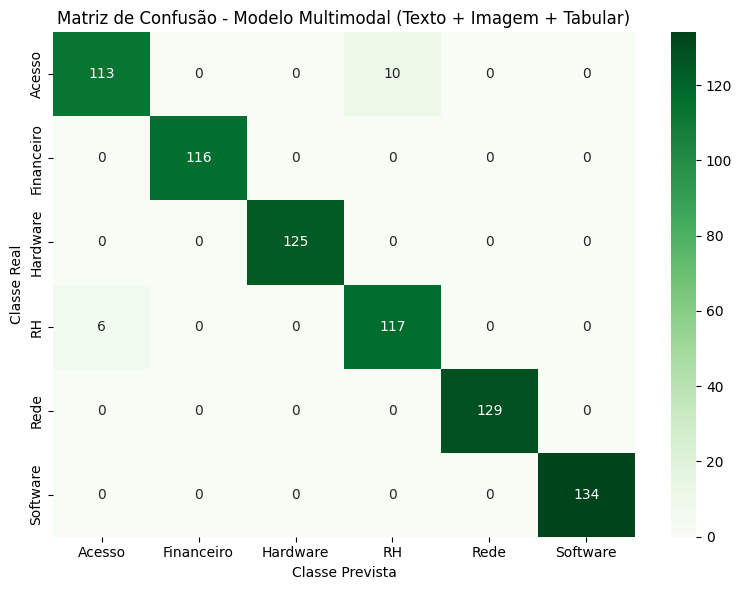


✅ Modelo Multimodal salvo em 'modelo_multimodal_final.keras'!


In [5]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Garantir acesso aos arquivos
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Localizar diretório
dir_path = None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'train_clean.csv' in files:
        dir_path = root
        break

# 2. Carregar Datasets Tabela e Embeddings gerados nos módulos anteriores
train_df = pd.read_csv(os.path.join(dir_path, 'train_clean.csv'))
val_df = pd.read_csv(os.path.join(dir_path, 'val_clean.csv'))
test_df = pd.read_csv(os.path.join(dir_path, 'test_clean.csv'))

img_train = np.load(os.path.join(dir_path, 'img_feats_train.npy'))
img_val = np.load(os.path.join(dir_path, 'img_feats_val.npy'))
img_test = np.load(os.path.join(dir_path, 'img_feats_test.npy'))

text_train = np.load(os.path.join(dir_path, 'text_embeds_train.npy'))
text_val = np.load(os.path.join(dir_path, 'text_embeds_val.npy'))
text_test = np.load(os.path.join(dir_path, 'text_embeds_test.npy'))

# 3. Processar Atributos Estruturados
ignored_cols = ['ticket_id', 'title', 'description', 'image_path', 'target_category', 'created_at', 'updated_at']
feature_cols = [c for c in train_df.columns if c not in ignored_cols]

X_train_num = train_df[feature_cols]
X_val_num = val_df[feature_cols]
X_test_num = test_df[feature_cols]

num_cols = X_train_num.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train_num.select_dtypes(include=['object', 'bool']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

tab_train = preprocessor.fit_transform(X_train_num)
tab_val = preprocessor.transform(X_val_num)
tab_test = preprocessor.transform(X_test_num)

# Encoding das classes da target
classes = np.unique(train_df['target_category'])
class_to_idx = {c: i for i, c in enumerate(classes)}
y_train_enc = np.array([class_to_idx[c] for c in train_df['target_category']])
y_val_enc = np.array([class_to_idx[c] for c in val_df['target_category']])
y_test_enc = np.array([class_to_idx[c] for c in test_df['target_category']])

# 4. Fusão das Três Modalidades (Early Fusion - Concatenacao)
X_train_multi = np.hstack([tab_train, text_train, img_train])
X_val_multi = np.hstack([tab_val, text_val, img_val])
X_test_multi = np.hstack([tab_test, text_test, img_test])

print(f"Dimensão final do vetor multimodal concatenado: {X_train_multi.shape[1]} atributos.")

# 5. Construção do Modelo Multimodal
model = models.Sequential([
    layers.Input(shape=(X_train_multi.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)

# 6. Treinamento
history = model.fit(
    X_train_multi, y_train_enc,
    validation_data=(X_val_multi, y_val_enc),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# 7. Avaliação e Comparação com o Baseline
test_loss, test_acc = model.evaluate(X_test_multi, y_test_enc, verbose=0)
y_pred_probs = model.predict(X_test_multi)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"\n==========================================")
print(f"🎯 RESULTADOS MODELO MULTIMODAL (FUSÃO)")
print(f"==========================================")
print(f"Acurácia no Teste: {test_acc:.4f}")
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_test_enc, y_pred, target_names=classes))

# 8. Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - Modelo Multimodal (Texto + Imagem + Tabular)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.show()

# 9. Salvar Modelo Treinado
model.save(os.path.join(dir_path, 'modelo_multimodal_final.keras'))
print("\n✅ Modelo Multimodal salvo em 'modelo_multimodal_final.keras'!")